In [187]:
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import pandas as pd
from EFC_learningfMRI.correlation import fit_correlation

In [188]:
# helper functions and globals

SESS    = [1, 2, 3]
N_CHORD = 8
N_SESS  = len(SESS)
N_RUN   = 10
N_VOX   = 100

REDS  = plt.cm.Reds(np.linspace(0.4, 0.95, len(SESS)))    # light -> dark = early -> late
BLUES = plt.cm.Blues(np.linspace(0.4, 0.95, len(SESS)))

Mflex    = pcm.CorrelationModel("flex", num_items=4, corr=None, cond_effect=True)

def make_shape(n_vox=200, shape_sd=1.0, n_cond=8, rng=None):
    """iid random shapes, zero spatial mean so they carry no average activity."""
    rng = np.random.default_rng() if rng is None else rng
    S = shape_sd * rng.standard_normal((n_cond, n_vox))
    return S - S.mean(axis=1, keepdims=True)


def make_truth(activity, S):
    """Ground-truth patterns: average activity `activity` (8,) on top of shapes `S` (8, n_vox)."""
    return np.asarray(activity, dtype=float)[:, None] + S


def simulate_runs(U, n_runs=30, noise_sd=1.0, rng=None):
    """Measure every chord once per run, with iid noise. Returns (Y, cond_vec, part_vec)."""
    rng = np.random.default_rng() if rng is None else rng
    n_cond, n_vox = U.shape
    Y = np.concatenate([U + noise_sd * rng.standard_normal((n_cond, n_vox))
                        for _ in range(n_runs)])
    cond_vec = np.tile(np.arange(n_cond), n_runs)
    part_vec = np.repeat(np.arange(n_runs), n_cond)
    return Y, cond_vec, part_vec

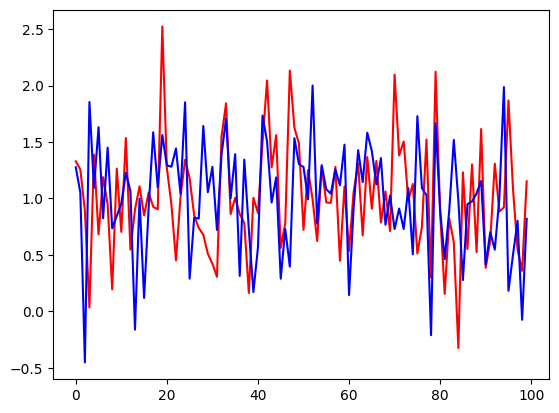

In [189]:
rng = np.random.default_rng(0)

activity = np.r_[np.full(4, 1), np.full(4, 1)]          # every chord drives the ROI equally, for now
S = make_shape(n_vox=N_VOX, shape_sd=1.0, rng=rng)
U = make_truth(activity, S)

plt.plot(U[:4].mean(axis=0), color='r')
plt.plot(U[4:].mean(axis=0), color='b')

In [190]:
# Simulate runs
Y, cond_vec, part_vec = simulate_runs(U, n_runs=N_RUN * N_SESS, noise_sd=1.0,) # rng=rng)
trained = cond_vec < 4
session = np.repeat(SESS, N_CHORD * N_RUN)

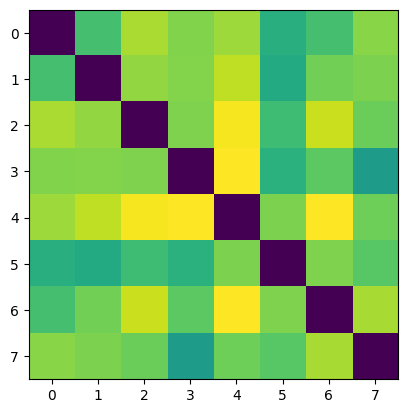

In [191]:
# ground truth G matrix
G, _ = pcm.est_G_crossval(Y, cond_vec, part_vec, X=pcm.indicator(part_vec))
D  = pcm.G_to_dist(G)

plt.imshow(D)

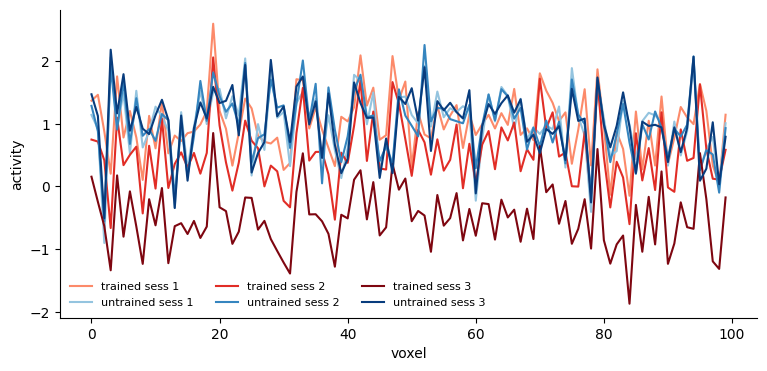

In [192]:
Y_eff = Y.copy()
Y_eff[(trained) & (session==2)] -= .5
Y_eff[(trained) & (session==3)] -= 1.5

fig, ax = plt.subplots(figsize=(9, 4))
for i, s in enumerate(SESS):
    ax.plot(Y_eff[trained  & (session == s)].mean(0), color=REDS[i],  label=f'trained sess {s}')
    ax.plot(Y_eff[~trained & (session == s)].mean(0), color=BLUES[i], label=f'untrained sess {s}')

ax.set_xlabel('voxel')
ax.set_ylabel('activity')
ax.legend(frameon=False, ncol=3, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)


session 1, distance trained: 1.5800038374277388, distance untrained: 1.6613278014188306
session 2, distance trained: 1.489645658723875, distance untrained: 1.4705885090000532
session 3, distance trained: 1.5017538932117507, distance untrained: 1.5466202065624313


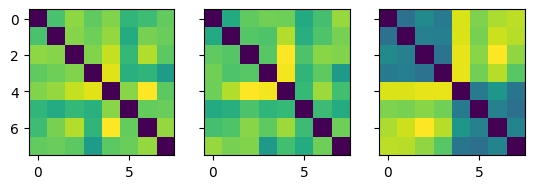

In [193]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True)

for i, s in enumerate(SESS):
    ax = axs[i]
    G_eff, _ = pcm.est_G_crossval(Y_eff[session==s], cond_vec[session==s], part_vec[session==s], X=pcm.indicator(part_vec[session==s]))
    D_eff  = pcm.G_to_dist(G_eff)

    print(f'session {s}, distance trained: {D_eff[:4, :4].mean()}, distance untrained: {D_eff[4:, 4:].mean()}')
    
    ax.imshow(D_eff)

plt.show()

In [195]:
sessions   = [1, 3]
keep       = (trained) & (pd.Series(session).isin(sessions))

obs_des    = {'cond_vec': pd.Series(session[keep]).astype(str) + ',' + pd.Series(cond_vec[keep]).astype(str),
              'part_vec': part_vec[keep]}
Dataset = pcm.Dataset(Y_eff[keep], obs_descriptors=obs_des)

r_indiv, r_group, SNR = fit_correlation(Dataset, Mflex)

print(f'rho={r_indiv[0]}, SNR={SNR[0]}')

Fitting Subj 0 model 0
Fitting group model 0
rho=1.0, SNR=1.0326173110748393


### Controlling the within-set cosine at fixed crossnobis distance

Start from the `Y` already simulated above and add, to **all four chords of a set**, the same shared pattern. Because that pattern is common to every chord, it **cancels in every pairwise difference** → the crossnobis distance does not move. But it *does* add to `G_to_cosine` → it raises the within-set cosine.

So the size of that shared pattern is the **cosine knob**, one per set (`cos_gain` below). Shrinking it across sessions makes the cosine fall in both trained and untrained, with the distances flat. The trained-only activity drop is your existing `-= 0.5 / 1.5` shift — a shared *constant* is just another shared pattern, so it also nudges the trained cosine down while lowering activity.

In [ ]:
def split_trained(M):
    """Mean of the trained (0:4) and untrained (4:8) blocks of a KxK matrix."""
    return np.r_[M[:4, :4].mean(), M[4:, 4:].mean()]

Y_sim = Y.copy()   # reuse the Y simulated above

# a pattern SHARED by all chords of a set cancels in every pairwise difference,
# so it leaves the crossnobis distance untouched but adds to the cosine.
# -> its size is the cosine knob, one trajectory per set.
rng = np.random.default_rng(1)
shared   = {'trained':   make_shape(n_vox=N_VOX, n_cond=1, rng=rng)[0],
            'untrained': make_shape(n_vox=N_VOX, n_cond=1, rng=rng)[0]}
cos_gain = {'trained':   {1: 3.0, 2: 1.5, 3: 0.0},   # <-- control the cosine per set,
            'untrained': {1: 3.0, 2: 1.5, 3: 0.0}}    #     per session (bigger -> higher cosine)

is_set = {'trained': trained, 'untrained': ~trained}
for chord, m_set in is_set.items():
    for s in SESS:
        Y_sim[m_set & (session == s)] += cos_gain[chord][s] * shared[chord]

# trained-only activity drop (same shift as before): a shared CONSTANT lowers activity
Y_sim[trained & (session == 2)] -= 0.5
Y_sim[trained & (session == 3)] -= 1.5

# read out activity, distance and cosine per session, as the pipeline does
act  = {c: np.array([Y_sim[m & (session == s)].mean() for s in SESS]) for c, m in is_set.items()}
dist = {c: np.zeros(N_SESS) for c in is_set}
cos  = {c: np.zeros(N_SESS) for c in is_set}
for i, s in enumerate(SESS):
    m = session == s
    G, _ = pcm.est_G_crossval(Y_sim[m], cond_vec[m], part_vec[m], X=pcm.indicator(part_vec[m]))
    dist['trained'][i], dist['untrained'][i] = split_trained(pcm.G_to_dist(G))
    cos['trained'][i],  cos['untrained'][i]  = split_trained(pcm.G_to_cosine(G))

fig, axs = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, metric, title in [(axs[0], act,  'overall activity'),
                          (axs[1], dist, 'crossnobis distance'),
                          (axs[2], cos,  'cosine similarity (PCM)')]:
    ax.plot(SESS, metric['trained'],   'o-', color=REDS[2],  label='trained')
    ax.plot(SESS, metric['untrained'], 'o-', color=BLUES[2], label='untrained')
    ax.set_title(title); ax.set_xlabel('session'); ax.set_xticks(SESS)
    ax.spines[['top', 'right']].set_visible(False)
axs[1].set_ylim(0, None); axs[2].set_ylim(0, None)
axs[0].legend(frameon=False)
fig.tight_layout()

for i, s in enumerate(SESS):
    print(f"sess {s}: act tr/untr = {act['trained'][i]:5.2f}/{act['untrained'][i]:4.2f} | "
          f"dist tr/untr = {dist['trained'][i]:.2f}/{dist['untrained'][i]:.2f} | "
          f"cos tr/untr = {cos['trained'][i]:.2f}/{cos['untrained'][i]:.2f}")